### Cupy em Opticas
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

#### Exemplo 1 - Processar dados relacionados a comunicações ópticas coerentes.
---
> O objetivo deste código é simular o processamento de dados em um sistema de comunicação óptica coerente, especificamente abordando os efeitos da dispersão no sinal transmitido e implementando uma técnica de equalização para melhorar a qualidade do sinal recebido.

O sinal gerado deve ser modificado para simular o efeito de dispersão. A dispersão é um fenômeno que ocorre em fibras ópticas e pode causar a alargamento e distorção do pulso do sinal, dificultando a recuperação da informação.

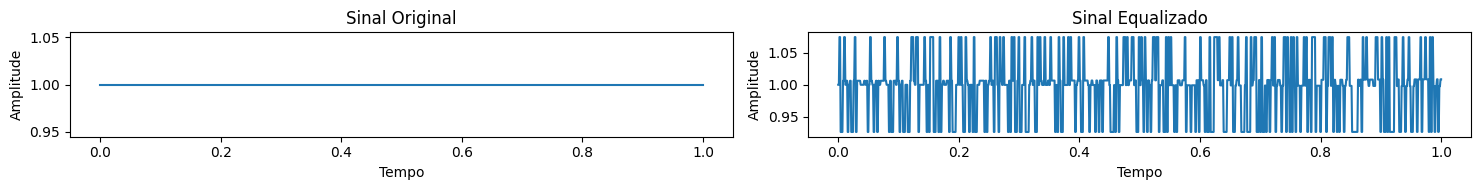

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

class OpticalCommunication:
    def __init__(self, num_amostra, tx_simbolo, tx_dispersao):
        self.num_amostra = num_amostra
        self.tx_simbolo = tx_simbolo
        self.tx_dispersao = tx_dispersao
        self.time = cp.linspace(0, 1, self.num_amostra)
        self.signal = cp.zeros(self.num_amostra, dtype=cp.complex128)

    def gerando_sinal(self):
        # Geração de um sinal usando modulação QPSK
        symbols = cp.random.randint(0, 4, self.num_amostra // 2)
        self.signal[0::2] = cp.exp(1j * cp.pi / 2 * symbols)
        self.signal[1::2] = cp.exp(1j * cp.pi / 2 * (symbols + 2))

    def dispersao(self):
        """Aplica a dispersão ao sinal gerado."""
        # Calculo do fator de dispersão
        dispersion = cp.exp(1j * cp.pi * self.tx_dispersao * self.time**2)
        self.signal *= dispersion
        self.original_signal = self.signal.copy()

    def equalizando_sinal(self):
        """Aplica um filtro de equalização ao sinal."""
        # Filtro passa-baixa para equalização
        freqs = cp.fft.fftfreq(self.num_amostra, d=1/self.tx_simbolo)
        filter_mask = cp.abs(freqs) < 0.5 * self.tx_simbolo

        # Transformada de Fourier
        signal_freq = cp.fft.fft(self.signal)
        # Aplicando o filtro
        equalized_signal_freq = signal_freq * filter_mask
        # Transformada inversa de Fourier
        self.signal = cp.fft.ifft(equalized_signal_freq)

    def plot_signal(self):
        """Plota o sinal original e o sinal equalizado."""
        plt.figure(figsize=(15, 2))
        plt.subplot(1, 2, 1)
        plt.title('Sinal Original')
        plt.plot(self.time.get(), cp.abs(self.original_signal).get())
        plt.xlabel('Tempo')
        plt.ylabel('Amplitude')

        plt.subplot(1, 2, 2)
        plt.title('Sinal Equalizado')
        plt.plot(self.time.get(), cp.abs(self.signal).get())
        plt.xlabel('Tempo')
        plt.ylabel('Amplitude')

        plt.tight_layout()
        plt.show()

def main():
    # Parâmetros da simulação
    num_amostra = 1024  # Número de amostras
    tx_simbolo = 1000  # Taxa de símbolos em Hz
    tx_dispersao = 0.01  # Coeficiente de dispersão

    # Instancia a classe de comunicação óptica
    optical = OpticalCommunication(num_amostra, tx_simbolo, tx_dispersao)

    # Geração e processamento do sinal
    optical.gerando_sinal()
    optical.dispersao()
    optical.equalizando_sinal()

    # Plota os sinais
    optical.plot_signal()

if __name__ == "__main__":
    main()


In [ ]:
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
from scipy.constants import c, h, k, e
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt

from optic.utils import parameters
from optic.comm.modulation import modulateGray
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm, lowPassFIR
from optic.plot import eyediagram
from optic.models.devices import mzm, iqm, photodiode, coherentReceiver

In [ ]:
def Tx_DSP(SpS, modulation, M, fator_size, pulso_type):
  """

  Esta parte contém todos os passos referente a primeira parte de toda simulação,
  que é a Tx_DSP e ela retorna o sinal formatado no pulso.

  Parameters:

    - SpS: int -> Taxa de amostragem
    - modulation: string -> tipo de modulação usada: OOK, PAM, QAM
    - M: int -> Ordem da modulação
    - fator_size: int -> Fator de multiplicação usado para gerar os sinais, se OOK será o tamanho da Samples.
    - pulso_type: string -> Modelo do pulso que será modelado

  Returns:
    - sigTX: np.array -> Sinal formatado no pulso preparado para modulação MZM
    - symbUp: np.array -> Amostras de simbolos
    - bitsTx: np.array -> Bits gerados

  """

  # Determinando o tamanho para gerar os bits
  if (modulation == "BPSK"):
    size = (fator_size)
    M = 2
  elif (modulation == "pam"):
    size = int((fator_size*np.log2(M)))
  elif (modulation == "qam"):
    size = int((fator_size*np.log2(M)))
  else:
    modulation == "OOK"
    print("Modulação será OOK")
    size = (fator_size)
    M = 2

  # Gerandos os bits aleatorios.
  bitsTx = np.random.randint(2, size=size)

  # Mapeando os bits e transformando em sinais eletricos e Normalizando
  if (size == fator_size):
    symbTx = M*bitsTx-1
    symbtx = pnorm(symbTx)
  else:
    symbTx = modulateGray(bitsTx, M, modulation)
    symbtx = pnorm(symbTx)

  # Aumentando o numero de amostras e filtrando com o pulso.
  symbUp = upsample(symbtx, SpS)
  pulse = pulseShape(pulso_type,SpS)
  pulse = pulse/np.max(np.abs(pulse))
  sigTx = firFilter(pulse, symbUp)

  return sigTx, symbUp, bitsTx, symbtx

In [ ]:
#######     Iniciando os Parametros default     #######

#######     Parametros de Simulacao
SpS = 16                                                                        # Taxa de amostragem, quantidade de amostra por simbolo
Rs  = 10e9                                                                      # Taxa de simbolos, largura de banda em (Hz)
Ts  = 1/Rs                                                                      # Periodo de simbolos em (s)
Fa  = 1/(Ts/SpS)                                                                # Frequencia de amostragem em (Hz)
Ta  = 1/Fa                                                                      # Periodo de amostragem em (s)

#######     Parametros da Modulação Optica
paramMZM = parameters()
paramMZM.Vpi = 2                                                                # Tensão π do modulador Mach-Zehnder (volts)
paramMZM.Vb = -paramMZM.Vpi/2                                                   # Tensão b do modulador Mach-Zehnder (volts)
Pi_dBm = -10                                                                    # Potência de entrada óptica no MZM (em dBm)

paramIQM = parameters()
paramIQM.Vpi = 2                                                                # Tensão π do modulador Mach-Zehnder (volts)
paramIQM.Vb = -paramIQM.Vpi                                                     # Tensão b do modulador Mach-Zehnder (volts)

#######     Parametros da geração de bits e inicio da Tx_DSP
# Obs.: Para modulação OOK, use M = 2
M = 2
modulation = "BPSK" #"pam" "qam"
fator_size = 10e4                                                               # Fator de multiplicação usado para gerar os sinais, se OOK será o tamanho da Samples.
pulso_type = "nrz"                                                              # Tipo do pulso que será gerado para modulação

sigTx, symbUp, bitsTx, symbtx = Tx_DSP(SpS, modulation, M, int(fator_size), pulso_type)

#######     Modulação Optica        #######
Pi = 10**(Pi_dBm/10)*1e-3                                                       # potência de sinal óptico em W na entrada do MZM
Ai = np.sqrt(Pi)
if (modulation == "qam"):
  sigTxo = iqm(Ai, -0.5*(paramMZM.Vb)*sigTx, paramMZM)
elif (modulation == "BPSK"):
  sigTxo = mzm(Ai, 2*sigTx, paramMZM)
else:
  sigTxo = mzm(Ai, -(paramMZM.Vb)*sigTx, paramMZM)

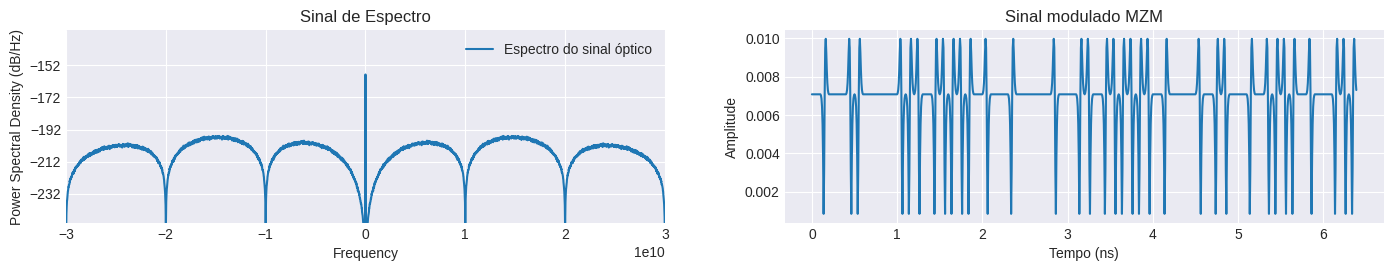

In [ ]:
# plota de graficos
# Parametros para a plotagem
t = np.arange(0, sigTxo.size)*(Ta/1e-9)
idX = np.arange(0,1023)

fig, axis = plt.subplots(1, 2, figsize=(17, 2.5))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].psd(np.abs(sigTxo)**2, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal óptico")
axis[0].set_xlim(-3*Rs,3*Rs)
axis[0].set_ylim(-250,-130)
axis[0].set_title("Sinal de Espectro")
axis[0].legend(loc="best")

axis[1].plot(t[idX], np.abs(sigTxo[idX]))
axis[1].set_xlabel("Tempo (ns)")
axis[1].set_ylabel("Amplitude")
axis[1].set_title("Sinal modulado MZM")
axis[1].grid(True)

# diagrama de olho
#eyediagram(sigTx, sigTx.size - SpS, SpS, plotlabel = "Sinal Elétrico")
#eyediagram(np.abs(sigTxo)**2, sigTxo.size - SpS, SpS,  plotlabel = "Sinal Óptico")

In [ ]:
def SSF_Simetrico(sigTxo, L_fibra, D, alpha, lmbd, gamma, hz, Fa, NFFT):
  """

  Esta função descreve a propagação de um pulso e usa a equação de
  Schrödinger para simular dispersão β2, perdas α e efeito kerr γ.

  Parameters:
    - sigTxo: np.array -> Sinal modulado
    - L_fibra: float -> Comprimento da fibra
    - D: float -> Parâmetro de dispersão
    - alpha: float -> Coeficiente de atenuação (dB/Km)
    - lmbd: float -> Comprimento de onda
    - gamma: float -> Coeficiente do efeito kerr
    - h: float -> Comprimento de cada interação
    - Fa: float -> Frequência de amostragem
    - NFFT: int -> Número de pontos do FFT

  Returns:
    - sigRx: np.array -> Sinal recebido apos a propagação no receptor
    - z: np.array -> Distância percorrida

  """
  alpha = 1e-3*alpha/(10*np.log10(np.exp(1)))                                   # Converte para linear Nepers/m
  beta2 = -(D*lmbd**2)/(2*np.pi*c)                                              # Segunda derivada da constante de propagação
  omega = 2*np.pi*Fa*np.fft.fftfreq(NFFT)                                       # Frequência de operação
  z = 0

  ####### Iniciando a manipulação da equação de Schrödinger
  sigRx = np.fft.fft(sigTxo)

  while z <= L_fibra:
    # Primeiro passo - operador linear
    sigRx = sigRx*np.exp(-alpha*(hz/2)+1j*(beta2/2)*(omega**2)*(hz/2))          # A(z + h , t) = A(z,t)e^{\frac{h}{2}\hat{D}}

    # Operador não linear
    sigRx = np.fft.ifft(sigRx)                                                  # Transformada inversa de Fourier
    sigRx = sigRx*np.exp(1j*gamma*(np.abs(sigRx)**2)*hz)                        # A(z + h , t) = A(z,t)e^{h\hat{N}}

    #Segundo passo - operador linear
    sigRx = np.fft.fft(sigRx)
    sigRx = sigRx*np.exp(-alpha*(hz/2)+1j*(beta2/2)*(omega**2)*(hz/2))          # A(z + h , t) = A(z,t)e^{\frac{h}{2}\hat{D}}

    z = z + hz                                                                  # Atualiza a distância percorrida

  sigRx = np.fft.ifft(sigRx)                                                    # Transformada inversa de Fourier

  return sigRx, z

In [ ]:
def edfa_lin(sigRx, gain, NF, Fc, Fa):
  """
  Esta função modela de forma simplificada o efeito de um amplificador óptico EDFA,
  retornando o sinal amplificado com a adição de ruído ASE (Amplified Spontaneous Emission).

  Parameters:
    - sigRx: np.array -> Sinal recebido após os calculos das imperfeições
    - gain: float -> Ganho óptico total do amplificador (em dB)
    - NF: int ->Figura de ruído do amplificador (em dB)
    - Fc: float -> Frequência central do sinal óptico (em Hz)
    - Fa: float -> Frequência de amostragem do sinal (em Hz)

  Returns:
    - sigRxo: np.array -> Sinal amplificado com ruído ASE adicionado

  """
  gain = 10**(gain/10)                                                          # Converte para linear
  NF = 10**(NF/10)                                                              # Converte para linear
  nsp = (gain*NF -1)/(2*(gain -1))                                              # Fator de emissão espontânea (ou fator de inversão de população)
  # h constante de planck que foi importada
  s_ase = (gain -1)*nsp*h*Fc                                                    # Densidade espectral do ruído de emissão espontânea amplificada (ASE)
  pt_noise = s_ase * Fa                                                         # Potência do ruído
  mean_noise = 0                                                                # Média do ruído
  noise    = np.random.normal(mean_noise, np.sqrt(pt_noise), sigRx.shape) + 1j*np.random.normal(mean_noise, np.sqrt(pt_noise), sigRx.shape)        # ruido gerado pelo EDFA

  sigRx = sigRx*gain + noise                                                   # Sinal com ruído

  return sigRx, noise

In [ ]:
##############      Processos no Canal Optico     ##############

#######     Parametros da fibra
L_fibra = 40e3                                                                  # Comprimento da fibra 40m
D     = 17e-6                                                                   # Parâmetro de dispersão s/(m²)
alpha = 0.2                                                                     # parametro para perdas dB/Km
lmbd   = 1550e-9                                                                # comprimento de onda
gamma = 1.22e-3                                                                 # parametro do efeito kerr W-1/m
hz    = 0.09e3                                                                   # comprimento de cada interação m
NFFT  = len(sigTxo)                                                             # numero de pontos do FFT

# Chamando a função que irá simular as dispersões, perdas e efeitos Kerr
#sigRx, z = SSF_Simetrico(sigTxo, L_fibra, D, alpha, lmbd, gamma, hz, Fa, NFFT)

# Chamando a função que irá colocar os ruídos gerados por um amplificador EDFA.
σASE  = 1e-6#1e-5
ruido = np.random.normal(0, np.sqrt(Fa*(σASE/(2*Rs))), sigTxo.size) + 1j*np.random.normal(0, np.sqrt(Fa*(σASE/(2*Rs))), sigTxo.size)
sigRx = sigTxo + ruido

# Calculando as tranformadas para comparar seus espectros
sigTxo_FFT = np.fft.fftshift(np.fft.fft(sigTxo)) / NFFT
sigRx_FFT = np.fft.fftshift(np.fft.fft(sigRx)) / NFFT
sigTxo_Px  = np.abs(sigTxo_FFT)**2
sigRx_Px  = np.abs(sigRx_FFT)**2
freq = np.fft.fftshift(np.fft.fftfreq(len(sigRx_FFT), Ta))

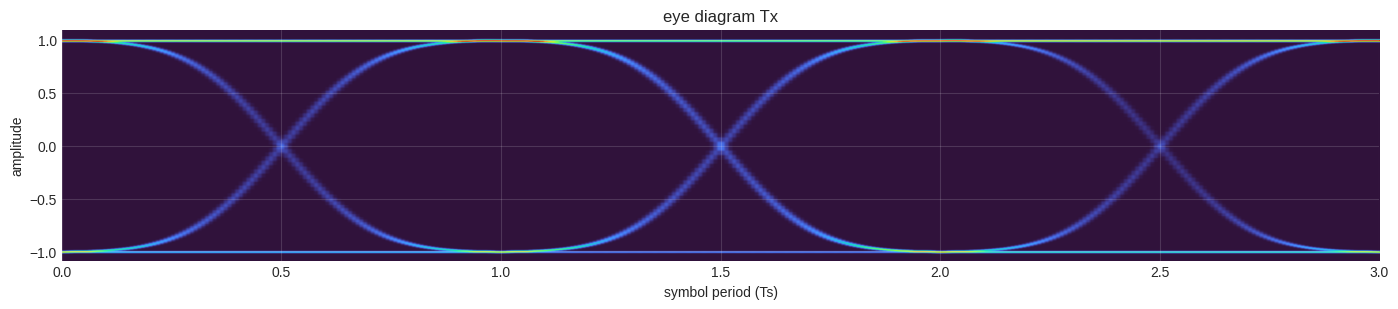

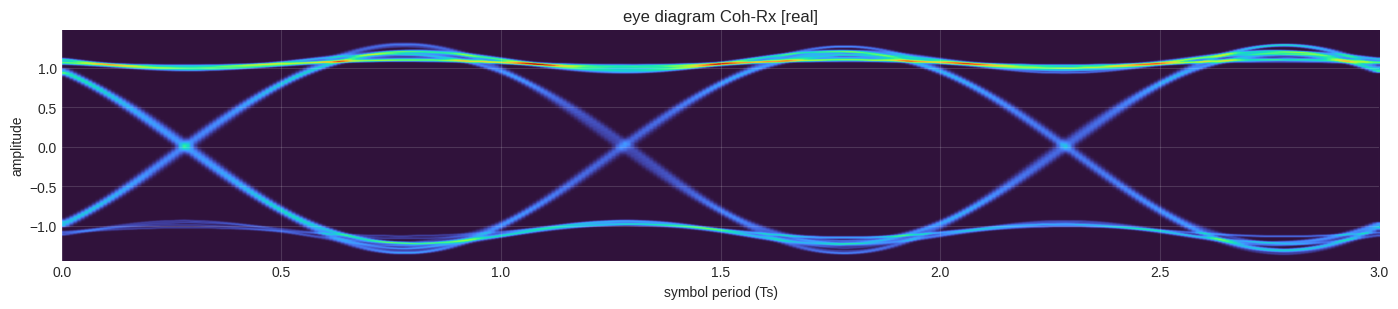

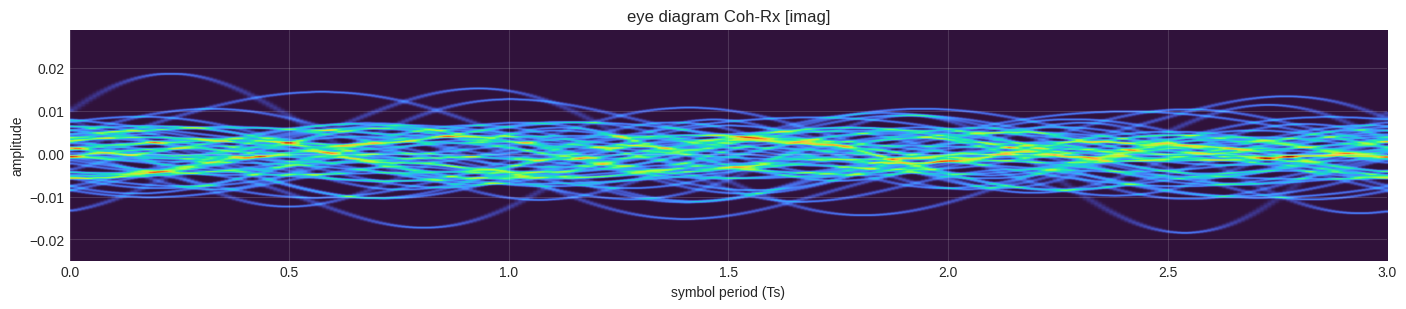

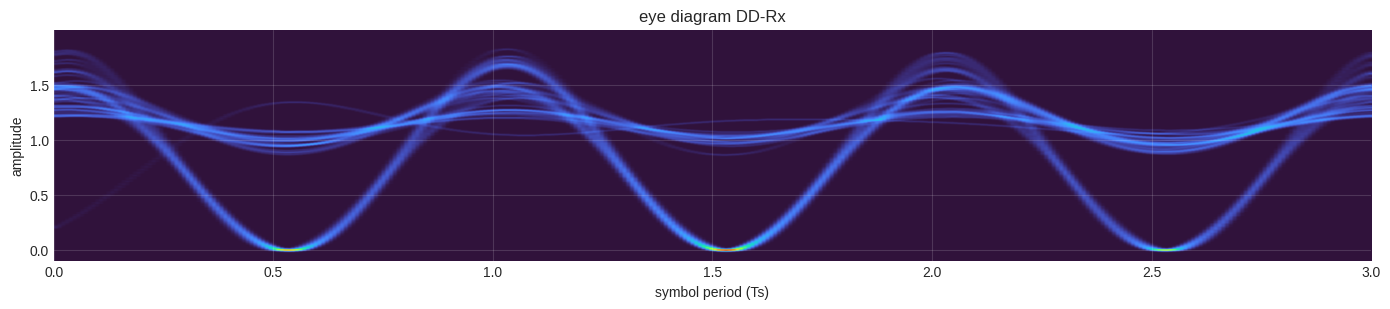

P_sig[opt] = -10.55 dBm
P_ase[opt] = -26.99 dBm
OSNR[est,Bsig] = 16.34 dB 

SNR[est] = 25.54 dB 

Total de erros contados = 0  
BER = 0.00e+00  


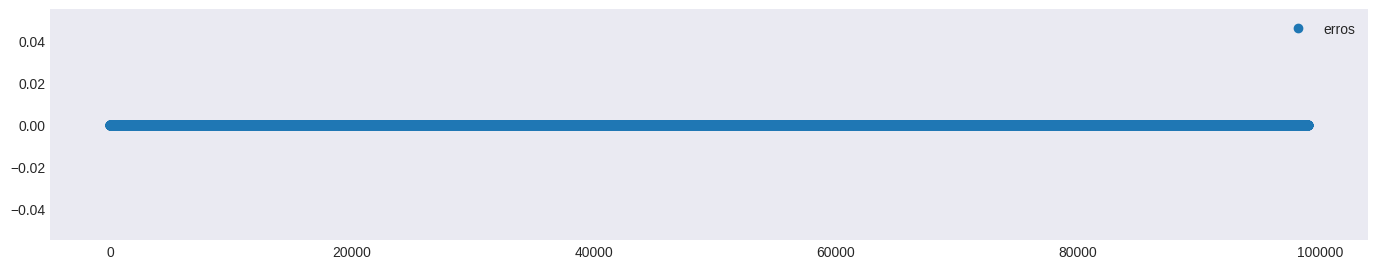

In [ ]:
# parâmetros do receptor
B   = 10e9      # banda do receptor em Hz
Plo_dBm  = 10   # potência do oscilador local
Δf_lo = 0       # desvio de frequência do oscilador local
ϕ_lo  = 0       # fase do oscilador local

Plo = 10**(Plo_dBm/10)*1e-3 # potência do oscilador local na entrada do receptor
### Recepcão coerente
Pin = signal_power(sigTxo) # Potência óptica média recebida

# oscilador local
t     = np.arange(0, sigTxo.size)*Ta
sigLO = np.sqrt(Plo)*np.exp(1j*(2*np.pi*Δf_lo*t + ϕ_lo))

paramPD = parameters()
paramPD.Fs = Fa

# receptor coerente
sigRx = coherentReceiver(sigTxo, sigLO, paramPD)
sigRx = pnorm(sigRx)

### Rx DSP
# filtragem Rx
N = 8001
h = lowPassFIR(B, Fa, N, typeF="rect")
sigRx = firFilter(h, sigRx)

# calculando a OSNR na simulação
sigTxo_Rx   = firFilter(h, sigTxo)
sigTxo_DDRx = firFilter(h, sigRx)
ruido_Rx    = firFilter(h, ruido)

OSNR = signal_power(sigTxo_Rx)/signal_power(ruido_Rx)

Nsamples = 10000

sigEye = sigRx.copy()
eyediagram(sigTx,  len(sigTx), SpS, plotlabel = "Tx", ptype="fancy")
eyediagram(sigEye[int(h.size/SpS)::], len(sigTx), SpS, plotlabel = "Coh-Rx", ptype="fancy")
eyediagram(np.abs(sigTxo_DDRx)**2,len(sigTxo_DDRx), SpS, plotlabel = "DD-Rx", ptype="fancy")

# captura amostras no meio dos intervalos de sinalização
sigRx = sigRx[0::SpS]
sigRx = pnorm(sigRx)

if modulation == "OOK":
    symbtx = (symbtx+1)/np.sqrt(signal_power(symbtx+1))

# Aplica a regra de decisão ótima
bitsRx = np.empty(bitsTx.size)
bitsRx[sigRx> symbtx.mean()] = 1
bitsRx[sigRx<= symbtx.mean()] = 0

discard = 500
ind = np.arange(discard, sigRx.size-discard)

# estima SNR do sinal recebido: SNR = Es/σ^2
SNR = 1/signal_power(sigRx[ind]-symbtx[ind])

err = np.logical_xor(bitsRx[ind],
                     bitsTx[ind])
BER = np.mean(err)

print("P_sig[opt] = %.2f dBm"%(10*np.log10(signal_power(sigTxo)/1e-3)))
print("P_ase[opt] = %.2f dBm"%(10*np.log10(signal_power(ruido_Rx)/1e-3)))
print("OSNR[est,Bsig] = %.2f dB \n"%(10*np.log10(OSNR)))
print("SNR[est] = %.2f dB \n"%(10*np.log10(SNR)))
print("Total de erros contados = %d  "%(err.sum()))
print("BER = %.2e  "%(BER))

plt.figure()
plt.plot(err,"o", label = "erros")
plt.legend()
plt.grid()